# Active-learning benchmark results

Plots from `al_benchmark/results.csv`. See [`../docs/AL_Benchmark.md`](../docs/AL_Benchmark.md) for the methodology and conclusions.

The benchmark replays four MEL-budget allocation policies against the SRG-score oracle at three budgets (1K / 5K / 25K synthon-equivalents) with five seeds. Lower regret and higher top-K recall are better.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))
from paths import PROJECT_ROOT

df = pd.read_csv(PROJECT_ROOT / 'al_benchmark' / 'results.csv')
df.head()

,policy,budget_total,budget_used,seed,n_mels_in_scope,n_mels_passing,n_observed,best_score,n_hits,regret_sum_topB,recall_top10,recall_top50,recall_top100,elapsed_s
0,baseline,1000,1198,0,7,7,1198,-43.301792,513,22523.914531,0.1,0.06,0.09,0.032
1,baseline,1000,1172,1,7,7,1172,-41.103557,495,22646.340449,0.0,0.00,0.04,0.022
2,baseline,1000,1205,2,7,7,1205,-41.718992,536,22176.412147,0.0,0.02,0.02,0.023
3,baseline,1000,1170,3,7,7,1170,-44.867604,530,21457.209300,0.1,0.04,0.07,0.021
4,baseline,1000,1196,4,7,7,1196,-41.103557,518,22316.842626,0.0,0.00,0.04,0.021


In [2]:
summary = df.groupby(['policy', 'budget_total']).agg(
    regret_mean=('regret_sum_topB', 'mean'),
    regret_sem=('regret_sum_topB', 'sem'),
    recall50_mean=('recall_top50', 'mean'),
    recall50_sem=('recall_top50', 'sem'),
    hits_mean=('n_hits', 'mean'),
    hits_sem=('n_hits', 'sem'),
).reset_index()
summary

,policy,budget_total,regret_mean,regret_sem,recall50_mean,recall50_sem,hits_mean,hits_sem
0,baseline,1000,22224.143811,208.227329,0.024,0.011662,518.4,7.145628
1,baseline,5000,56976.464252,1186.627875,0.236,0.033705,2593.0,37.308176
2,baseline,25000,160238.009305,8680.686467,1.000,0.000000,10073.2,6.792643
3,greedy,1000,20062.291617,710.609721,0.020,0.012649,553.8,8.890444
4,greedy,5000,86652.276123,8073.929678,0.124,0.049960,1726.8,200.622382
5,greedy,25000,287864.907081,29991.497697,0.464,0.135263,5737.8,731.817081
6,ts,1000,20396.819879,139.368313,0.028,0.010198,544.4,5.767148
7,ts,5000,55711.044428,797.144061,0.188,0.044542,2586.4,19.294041
8,ts,25000,149076.923807,1426.412142,1.000,0.000000,10072.6,4.739198
9,ucb,1000,20412.534422,107.616973,0.032,0.012000,539.0,5.147815


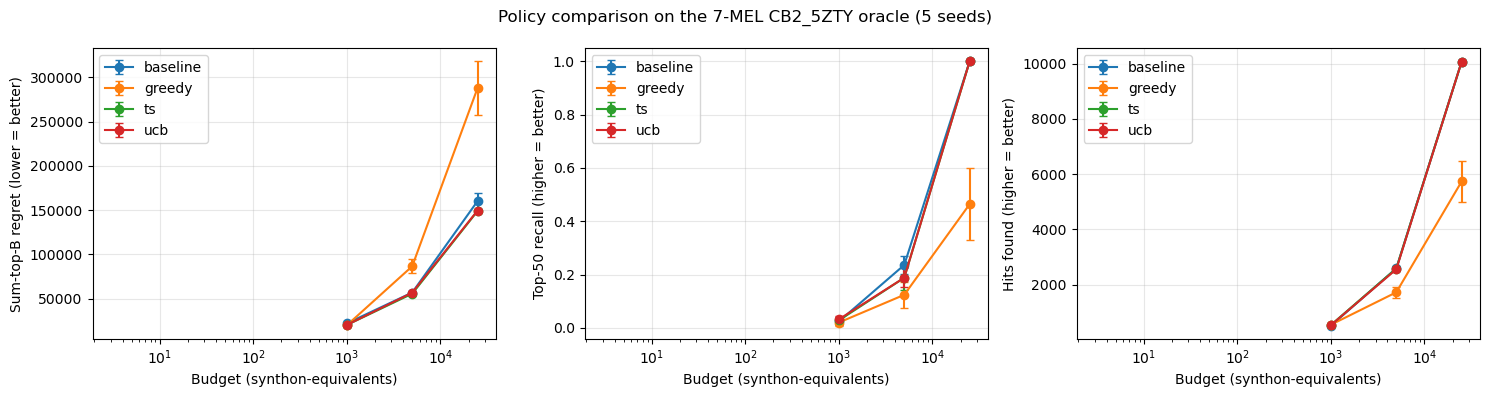

In [3]:
# Regret vs budget (lower is better) — one line per policy.
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, (metric, ylabel, lower_better) in zip(axes, [
    ('regret_sum_topB', 'Sum-top-B regret (lower = better)', True),
    ('recall_top50',    'Top-50 recall (higher = better)',    False),
    ('n_hits',          'Hits found (higher = better)',       False),
]):
    for policy, sub in df.groupby('policy'):
        agg = sub.groupby('budget_total')[metric].agg(['mean', 'sem']).reset_index()
        ax.errorbar(agg['budget_total'], agg['mean'], yerr=agg['sem'],
                    marker='o', capsize=3, label=policy)
    ax.set_xscale('log')
    ax.set_xlabel('Budget (synthon-equivalents)')
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend()
fig.suptitle('Policy comparison on the 7-MEL CB2_5ZTY oracle (5 seeds)')
fig.tight_layout()
plt.show()

## Reading the result

Numbers from the most recent run (see summary table above):

| Budget | baseline regret | greedy regret | TS regret | UCB regret |
|---|---|---|---|---|
| 1K   | ~22.2K | ~20.1K | ~20.4K | ~20.4K |
| 5K   | ~57.0K | ~86.7K (worse) | ~55.7K | ~56.8K |
| 25K  | ~160K  | ~288K (much worse) | ~149K | ~150K |

**TS and UCB are slightly but consistently better than the baseline at every budget; greedy is dramatically worse at high budgets** (it over-commits to the apparent best MEL early and forgoes hits hiding in the other MELs' tails).

Caveat: the oracle covers only 7 MELs (4 of which have ≥10K synthons). The conclusion is suggestive, not decisive — see the writeup's "What we don't know yet" section.